# Polynomial Regression

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### About Dataset

The Ice Cream Selling CSV file is a dataset that is commonly used by beginners in machine learning, particularly for practicing polynomial regression. It is a straightforward and well-suited dataset for individuals who are starting their journey in machine learning and want to gain hands-on experience with regression algorithms.

The dataset is organized in a tabular format and contains two columns. The first column represents the temperature values, which serve as the independent variable in the regression analysis. The temperature values are typically measured in degrees Celsius or Fahrenheit. The second column corresponds to the number of units of ice cream sold, which is the dependent variable in the regression analysis.

By using this dataset, beginners can explore the relationship between temperature and ice cream sales and apply polynomial regression techniques to predict the number of ice cream units sold based on temperature. This dataset offers a practical and relatable example for understanding and implementing regression algorithms in machine learning.

In [2]:
df = pd.read_csv("Ice_cream data.csv")
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [3]:
df.shape

(49, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


In [5]:
df.describe()

,Temperature (°C),Ice Cream Sales (units)
count,49.000000,49.000000
mean,0.271755,15.905308
std,2.697672,12.264682
min,-4.662263,0.328626
25%,-2.111870,4.857988
50%,0.688781,12.615181
75%,2.784836,25.142082
max,4.899032,41.842986


In [6]:
df.duplicated().sum()   #No duplicates

0

In [7]:
df.isnull().sum()   #No missing values

Temperature (°C)           0
Ice Cream Sales (units)    0
dtype: int64

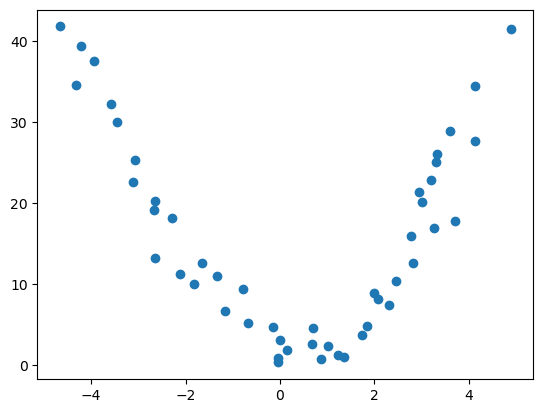

In [8]:
## Scatter plot
plt.scatter(x=df['Temperature (°C)'],y=df['Ice Cream Sales (units)'])
plt.show()                  # A polynomial curve can be observed.

In [9]:
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


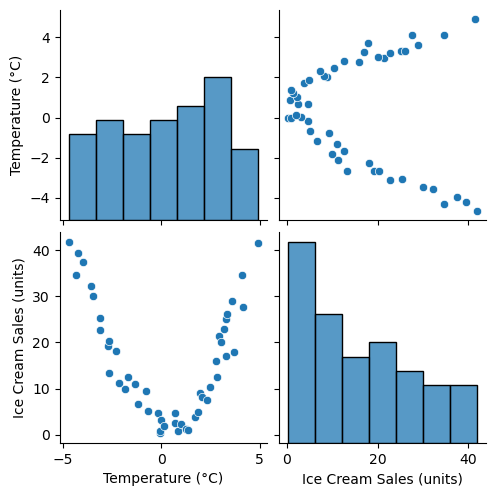

In [10]:
plt.show(sns.pairplot(df))

In [11]:
## independent feature
X = df[['Temperature (°C)']]
X.head(3)

,Temperature (°C)
0,-4.662263
1,-4.316559
2,-4.213985


In [12]:
# dependent feature
y = df['Ice Cream Sales (units)']
y 

0     41.842986
1     34.661120
2     39.383001
3     37.539845
4     32.284531
5     30.001138
6     22.635401
7     25.365022
8     19.226970
9     20.279679
10    13.275828
11    18.123991
12    11.218294
13    10.012868
14    12.615181
15    10.957731
16     6.689123
17     9.392969
18     5.210163
19     4.673643
20     0.328626
21     0.897603
22     3.165600
23     1.931416
24     2.576782
25     4.625689
26     0.789974
27     2.313806
28     1.292361
29     0.953115
30     3.782570
31     4.857988
32     8.943823
33     8.170735
34     7.412094
35    10.336631
36    15.996620
37    12.568237
38    21.342916
39    20.114413
40    22.839406
41    16.983279
42    25.142082
43    26.104740
44    28.912188
45    17.843957
46    34.530743
47    27.698383
48    41.514822
Name: Ice Cream Sales (units), dtype: float64

In [13]:
# Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [14]:
X_train.shape

(34, 1)

In [15]:
## simple linear regression on this won't work efficiently as we have increasing and decreasing slopes in the curve
# Still implement it and see!

#Standard Scaling not required as both features have similar units

from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train,y_train)

LinearRegression()

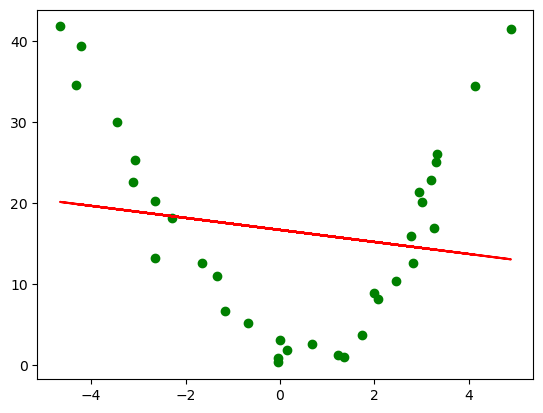

In [16]:
# Visualize the model
plt.scatter(X_train,y_train,color='green')
plt.plot(X_train,regression.predict(X_train),color='red')
plt.show()              # Look it does'nt work at all

In [17]:
from sklearn.metrics import r2_score
score = r2_score(y_test,regression.predict(X_test))
score           # Very Low accuracy

0.013527080157335392

In [18]:
# Lets apply polynomial transformation
from sklearn.preprocessing import PolynomialFeatures

In [19]:
poly = PolynomialFeatures(degree=2,include_bias=True)   # include bias means we will have an intercept.
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
#Same technique applied on test data,i.e., no new features created for testing. Good for testing based on training!

In [20]:
X_train_poly    # 1st column- x^0, 2nd - x^1, 3rd- x^2

array([[ 1.00000000e+00, -3.10844012e+00,  9.66239999e+00],
       [ 1.00000000e+00,  3.21136614e+00,  1.03128725e+01],
       [ 1.00000000e+00,  3.27004407e+00,  1.06931882e+01],
       [ 1.00000000e+00,  4.13086796e+00,  1.70640701e+01],
       [ 1.00000000e+00, -1.32637898e+00,  1.75928121e+00],
       [ 1.00000000e+00, -2.65228679e+00,  7.03462523e+00],
       [ 1.00000000e+00, -1.17312327e+00,  1.37621820e+00],
       [ 1.00000000e+00,  6.88780908e-01,  4.74419139e-01],
       [ 1.00000000e+00,  2.07510060e+00,  4.30604249e+00],
       [ 1.00000000e+00,  1.74000001e+00,  3.02760004e+00],
       [ 1.00000000e+00, -4.66226268e+00,  2.17366933e+01],
       [ 1.00000000e+00,  3.33593241e+00,  1.11284451e+01],
       [ 1.00000000e+00,  1.99931037e+00,  3.99724195e+00],
       [ 1.00000000e+00, -3.45571170e+00,  1.19419433e+01],
       [ 1.00000000e+00,  1.35981267e+00,  1.84909051e+00],
       [ 1.00000000e+00, -2.28826400e+00,  5.23615213e+00],
       [ 1.00000000e+00,  2.78483646e+00

In [21]:
# Now implementing this in linear model
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train_poly,y_train)

LinearRegression()

In [22]:
y_pred = regression.predict(X_test_poly)

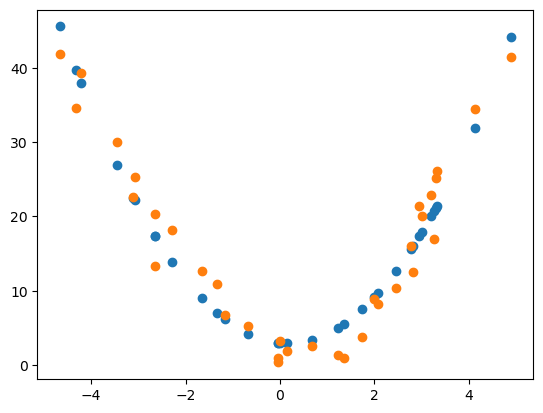

In [23]:
# Scatter plot
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,y_train)
plt.show()

In [24]:
# R2 score
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
score           # Good accuracy

0.899454349424936

In [25]:
regression.coef_    # 2nd and 3rd are coefficients of x^1 and x^2 

array([ 0.        , -0.58415772,  1.83742584])

In [26]:
regression.intercept_

2.9317024461806707

In [27]:
## Prediction of new data
regression.predict(poly.transform([[2.75]]))

array([15.22080159])

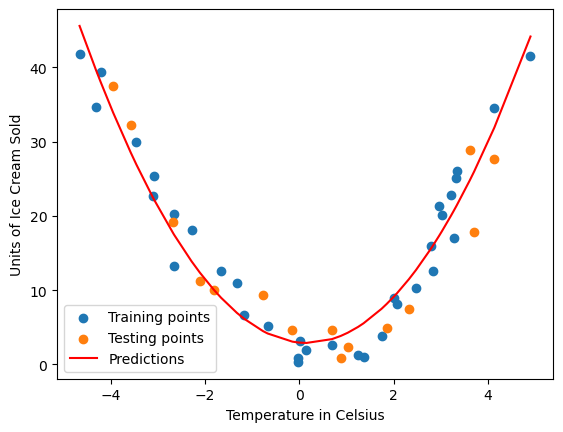

In [28]:
# Common Visualization
plt.scatter(X_train,y_train,label='Training points')
plt.scatter(X_test,y_test,label='Testing points')
plt.plot(X,regression.predict(poly.transform(X)),label='Predictions',color='red')
plt.xlabel("Temperature in Celsius")
plt.ylabel("Units of Ice Cream Sold")
plt.legend()
plt.show()

### Using Pipeline

In [29]:
from sklearn.pipeline import Pipeline

In [30]:
def poly_regr(degree):
    poly = PolynomialFeatures(degree = degree,include_bias=True)
    regr = LinearRegression()
    poly_regression = Pipeline([        # Pipeline chains together multiple steps of data preprocessing 
        ("poly_features",poly),         # and modeling into a single, streamlined unit.
        ("linear_regression",regr)
    ])

    poly_regression.fit(X_train,y_train)
    y_pred = poly_regression.predict(X_test)

    r2 = r2_score(y_test,y_pred)
    print(f"R2 score for degree {degree} is {r2}")

    plt.scatter(X_train,y_train,label='Training points')
    plt.scatter(X_test,y_test,label='Testing points')
    plt.plot(X,poly_regression.predict(X),label='Predictions',color='red',linewidth=3)
    plt.xlabel("Temperature in Celsius")
    plt.ylabel("Units of Ice Cream Sold")
    plt.legend(loc='upper right')
    plt.show()

R2 score for degree 2 is 0.899454349424936


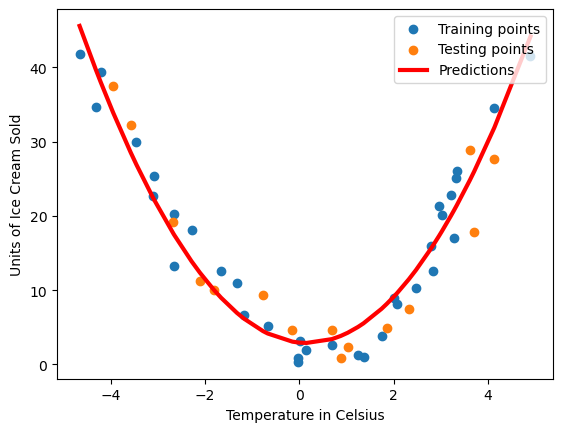

In [31]:
poly_regr(2)

R2 score for degree 3 is 0.9011541169923962


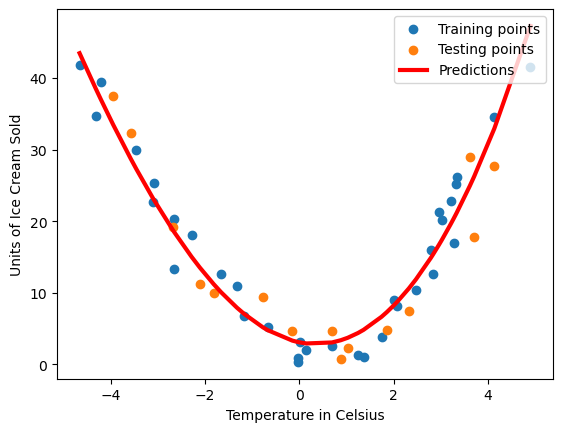

In [32]:
poly_regr(3)

R2 score for degree 4 is 0.8885821666860184


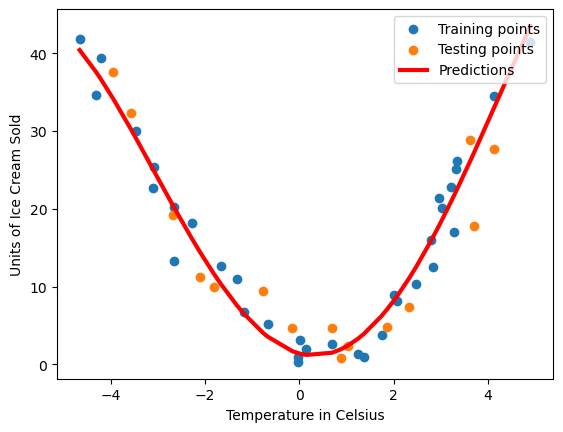

In [33]:
poly_regr(4)

R2 score for degree 5 is 0.8587722188889415


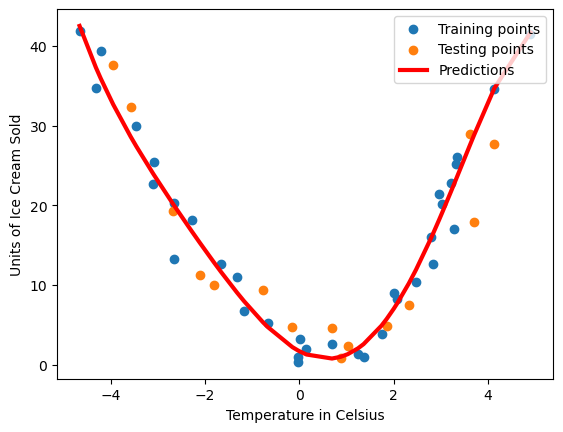

In [34]:
poly_regr(5)

R2 score for degree 15 is 0.8902405335847836


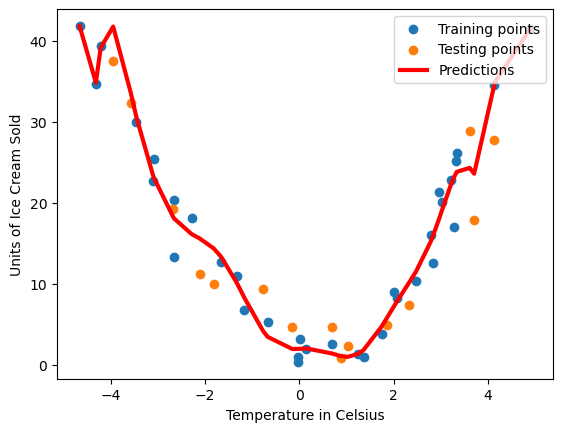

In [35]:
poly_regr(15)       # if i take a higher degree, as observed 15, then the model will start overfitting all the datapoints on single curve.